### Build a basic chatbot  with langgraph (Graph API)

In [54]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [55]:
class State(TypedDict):
    # Mesages have the type "list". The 'add_messages' function
    # in the annotation defined how this state key should be updated
    # (in this case, it appends the messages to the list, rather than overwriting them).
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [56]:
graph_builder

In [57]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [58]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# llm = ChatGroq(model="llamma2-8b-8192")
# llm


In [59]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DEE7C0F710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DEE7B8B7D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [60]:
## Node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [61]:
graph_builder = StateGraph(State)

## Adding nodes
graph_builder.add_node("llmchatbot", chatbot)
## adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)
# graph_builder

## Compiling the graph
graph = graph_builder.compile()


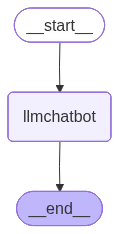

In [62]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [63]:
response = graph.invoke({"messages":"Hi there!"})


In [64]:
response["messages"]

[HumanMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='37ca09c1-8fe8-446e-aa57-739fa7cd578c'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 38, 'total_tokens': 62, 'completion_time': 0.047036281, 'completion_tokens_details': None, 'prompt_time': 0.000952199, 'prompt_tokens_details': None, 'queue_time': 0.162440971, 'total_time': 0.04798848}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d8548-a443-7263-8401-2d6477d81d17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 24, 'total_tokens': 62})]

In [65]:
for event in graph.stream({"messages":"Hi there!"}):
    # print(event)
    for value in event.values():
        print(value["messages"][-1].content)

It's nice to meet you. Is there something I can help you with or would you like to chat?


### Chatbot with tool

In [69]:
from langchain_tavily import TavilySearch

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")


tool = TavilySearch(max_results=2)
tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Paris',
   'title': 'Paris - Wikipedia',
   'content': "| | * v * t * e Communes in the Paris metropolitan area | | --- | | Population over 2 million | * Paris | | Population over 100,000 | * Argenteuil * Boulogne-Billancourt * Montreuil * Saint-Denis | | Population over 75,000 | * Asnières-sur-Seine * Aubervilliers * Aulnay-sous-Bois * Champigny-sur-Marne * Colombes * Courbevoie * Créteil * Nanterre * Rueil-Malmaison * Versailles * Vitry-sur-Seine | | Population over 50,000 | * Antony * Le Blanc-Mesnil * Bobigny * Bondy * Cergy * Chelles * Clamart * Clichy * Corbeil-Essonnes * Drancy * Épinay-sur-Seine * Évry-Courcouronnes * Fontenay-sous-Bois * Issy-les-Moulineaux * Ivry-sur-Seine * Levallois-Perret * Maisons-Alfort * Massy * Meaux * Neuilly-sur-Seine * Noisy-le-Grand * Pantin * Saint-Maur-des-Fossés * Saint-Ouen-sur-Seine * Sar

In [71]:
## custom function
def multiply(a:int, b:int) -> int:
    """Multiply two numbers
    Args:
        a: first number
        b: second number
    Returns:
        The product of a and b
    
    """
    return a * b


In [72]:
tools = [tool, multiply]

In [73]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DEE7C0F710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DEE7B8B7D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input

In [ ]:
## Sategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

## node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## graph
graph_builder = StateGraph(State)
graph_builder.add_node("tool_calling_llm", )
graph_builder.add_node("tools", ToolNode(tools))

## Add edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm", 
    ## if the latest message(result) from assistant is a tool call -> tools_condition routes to tools
    #if the message from assistant is not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", END)